<a href="https://colab.research.google.com/github/Areefbaba/Amazon-Kindle-Sentiment-Analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import pickle

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
df = pd.read_csv("all_kindle_review.csv", engine='python')

print(df.shape)
df.head()

(12000, 11)


,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    12000 non-null  int64 
 1   Unnamed: 0      12000 non-null  int64 
 2   asin            12000 non-null  object
 3   helpful         12000 non-null  object
 4   rating          12000 non-null  int64 
 5   reviewText      12000 non-null  object
 6   reviewTime      12000 non-null  object
 7   reviewerID      12000 non-null  object
 8   reviewerName    11962 non-null  object
 9   summary         11998 non-null  object
 10  unixReviewTime  12000 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 1.0+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,0
asin,0
helpful,0
rating,0
reviewText,0
reviewTime,0
reviewerID,0
reviewerName,38
summary,2


In [ ]:
df.describe(include='all')

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
count,12000.00000,12000.000000,12000,12000,12000.000000,12000,12000,12000,11962,11998,1.200000e+04
unique,NaN,NaN,2114,393,NaN,12000,1953,7614,6735,10126,NaN
top,NaN,NaN,B002AJ7X2C,"[0, 0]",NaN,If Terry Pratchett's Samuel Vimes and Dashiel ...,"02 18, 2013",A320TMDV6KCFU,Amazon Customer,Good,NaN
freq,NaN,NaN,111,5690,NaN,1,37,125,659,41,NaN
mean,5999.50000,10024.275667,NaN,NaN,3.250000,NaN,NaN,NaN,NaN,NaN,1.344537e+09
std,3464.24595,10502.233123,NaN,NaN,1.421619,NaN,NaN,NaN,NaN,NaN,4.369374e+07
min,0.00000,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,9.602496e+08
25%,2999.75000,2999.750000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,1.316218e+09
50%,5999.50000,5999.500000,NaN,NaN,3.500000,NaN,NaN,NaN,NaN,NaN,1.356826e+09
75%,8999.25000,12475.750000,NaN,NaN,4.250000,NaN,NaN,NaN,NaN,NaN,1.376870e+09


In [ ]:
print(df.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'asin', 'helpful', 'rating', 'reviewText',
       'reviewTime', 'reviewerID', 'reviewerName', 'summary',
       'unixReviewTime'],
      dtype='object')


In [ ]:
# Index([
# 'reviewText',
# 'summary',
# 'overall'
# ])

In [ ]:
def create_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"
df['sentiment'] = df['rating'].apply(create_sentiment)

In [ ]:
def create_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(create_sentiment)

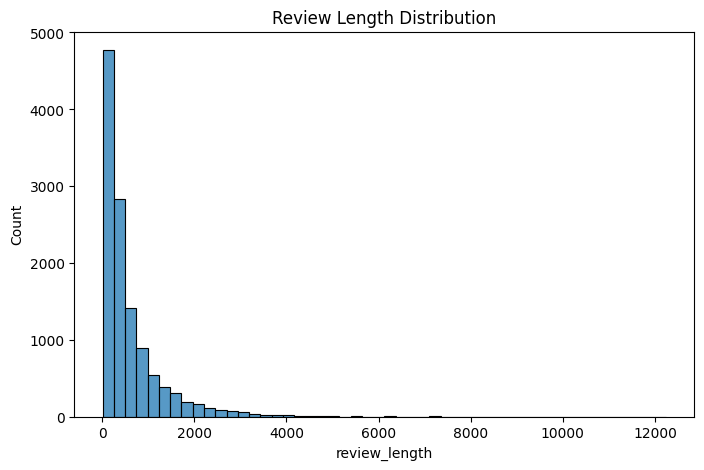

In [ ]:
df['review_length'] = df['reviewText'].astype(str).apply(len)
plt.figure(figsize=(8,5))

sns.histplot( df['review_length'],bins=50)

plt.title("Review Length Distribution")
plt.show()

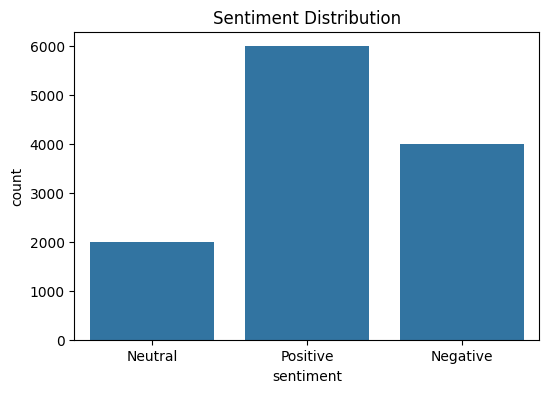

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['sentiment'])
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)

In [ ]:
df['clean_review'] = df['reviewText'].apply(clean_text)

In [ ]:
df['word_count'] = df['clean_review'].apply(lambda x: len(x.split()))

In [ ]:
df['char_count'] = df['clean_review'].apply(len)

In [ ]:
X = df['clean_review']
y = df['sentiment']

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf,y, test_size=0.2,random_state=42,stratify=y)

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))
print(classification_report(
    y_test,
    lr_pred
))

Accuracy: 0.7554166666666666
              precision    recall  f1-score   support

    Negative       0.77      0.81      0.79       800
     Neutral       0.51      0.17      0.26       400
    Positive       0.77      0.91      0.83      1200

    accuracy                           0.76      2400
   macro avg       0.68      0.63      0.63      2400
weighted avg       0.73      0.76      0.72      2400



In [ ]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, nb_pred))
print(classification_report(
    y_test,
    nb_pred
))

Accuracy: 0.7329166666666667
              precision    recall  f1-score   support

    Negative       0.75      0.78      0.77       800
     Neutral       0.75      0.01      0.01       400
    Positive       0.72      0.94      0.82      1200

    accuracy                           0.73      2400
   macro avg       0.74      0.58      0.53      2400
weighted avg       0.74      0.73      0.67      2400



In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, rf_pred))
print(classification_report(
    y_test,
    rf_pred
))

Accuracy: 0.7091666666666666
              precision    recall  f1-score   support

    Negative       0.72      0.74      0.73       800
     Neutral       0.71      0.01      0.02       400
    Positive       0.70      0.92      0.80      1200

    accuracy                           0.71      2400
   macro avg       0.71      0.56      0.52      2400
weighted avg       0.71      0.71      0.65      2400



In [ ]:
svm = LinearSVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, svm_pred))
print(classification_report(
    y_test,
    svm_pred
))

Accuracy: 0.73
              precision    recall  f1-score   support

    Negative       0.74      0.78      0.76       800
     Neutral       0.42      0.24      0.31       400
    Positive       0.78      0.86      0.82      1200

    accuracy                           0.73      2400
   macro avg       0.64      0.63      0.63      2400
weighted avg       0.71      0.73      0.71      2400



In [ ]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "Linear SVM"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ]
})
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.755417
1,Naive Bayes,0.732917
3,Linear SVM,0.730000
2,Random Forest,0.709167


In [ ]:
best_model = svm

best_model = svm

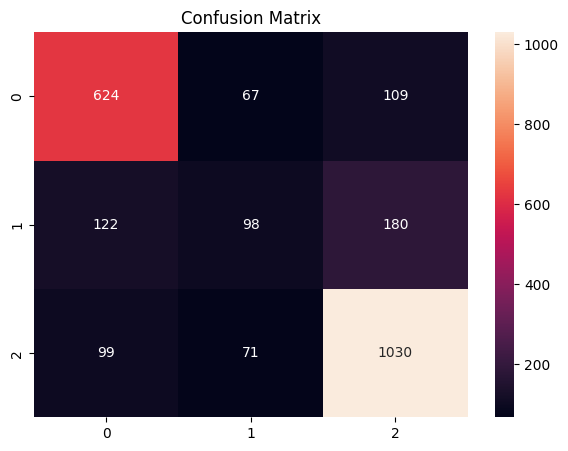

In [ ]:
cm = confusion_matrix(
    y_test,
    svm_pred
)
plt.figure(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
pickle.dump(best_model,open("sentiment_model.pkl","wb"))

In [ ]:
pickle.dump(tfidf,open("tfidf.pkl","wb"))

In [ ]:
def predict_sentiment(review):
    review = clean_text(review)
    review = tfidf.transform([review])
    prediction = best_model.predict(review)
    return prediction[0]

In [ ]:
sample = """
This book is amazing.
Very informative and useful.
"""
print(predict_sentiment(sample))

Positive


In [ ]:
positive_reviews = df[df['sentiment']=="Positive"]

In [ ]:
negative_reviews = df[df['sentiment']=="Negative"]

In [ ]:
print("Positive Reviews:",
      len(positive_reviews))
print("Negative Reviews:",
      len(negative_reviews))

Positive Reviews: 6000
Negative Reviews: 4000
